# First-order reversal curve processing with PmagPy

This notebook develops a FORC diagram from the measured reversal curves, one processing decision at a time. It uses the new `pmagpy.forc` module and compares the two published local-regression approaches that underpin modern FORC processing:

- Harrison and Feinberg (2008) nearest-neighbor LOESS, the method introduced with FORCinel.
- Egli (2013) VARIFORC, which varies horizontal and vertical smoothing independently.

The module's staged workflow, one-call `run_forc_pipeline` interface, output organization, and final color palette follow Maxwell Brown's **FORCme** package. The numerical regression is independently tied to the published equations and the FORCinel 3.08 procedure where FORCme deliberately uses a different, fixed-ellipse smoothing strategy. FORCme-derived portions are attributed in `pmagpy.forc` and retained under its MIT license.

| Program component | Primary provenance | PmagPy implementation |
|---|---|---|
| Staged preparation and one-call/batch workflow | FORCme | `run_forc_pipeline`, with auditable raw, conditioned, processed, and result stages |
| FORC curve plotting and final palette | FORCme | FORCme-compatible plotting name and exact green-red version-2 color stops |
| Constant isotropic smoothing | Harrison and Feinberg (2008) / FORCinel | nearest-neighbor quadratic LOESS with tricube weights |
| Variable anisotropic smoothing | Egli (2013) / FORCinel 3.08 | rectangular variable smoothing and Egli's continuous edge weights |
| Calibration parsing, drift, and baseline safeguards | Published/FORCinel behavior plus validation | retains calibration blocks and prevents unsupported baseline extrapolation |

The goal is not simply to produce a colored diagram. By the end, you should be able to explain what is differentiated, why smoothing is required, how the smoothing geometry affects resolution, and which processing choices should be reported with a result.

## Learning objectives

1. Recognize the reversal field, measurement field, coercivity coordinate, and interaction/bias coordinate.
2. Apply calibration-drift and endpoint corrections deliberately.
3. Compare constant isotropic and variable anisotropic local regression.
4. Use uncertainty and signal-to-noise maps to distinguish stable structure from visually attractive noise.
5. Extract a reproducible one-dimensional FORC profile.

## Interactive synthetic FORC experiment

Use **Play** or the slider below to step through a synthetic FORC acquisition. The left panel adds measured reversal curves in acquisition order. For every animation frame, the right panel recalculates the local quadratic regression using only the curves acquired up to that point; it is not simply revealing a finished image. As progressively lower reversal fields are measured, the supported area in $(H_c,H_u)$ space expands and the two synthetic coercivity populations become resolved.

The synthetic sample is an ensemble of rectangular hysterons with two coercivity populations and a narrow distribution of bias fields. It is deliberately simple: the animation explains sampling geometry and numerical construction, not the full physics of interacting natural particles.

In [1]:
from pathlib import Path
import sys

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

notebook_dir = Path.cwd()
if notebook_dir.name != "FORC_notebooks":
    candidate = notebook_dir / "FORC_notebooks"
    if candidate.exists():
        notebook_dir = candidate
pmag_checkout = notebook_dir.parents[1] / "PmagPy"
if pmag_checkout.exists():
    sys.path.insert(0, str(pmag_checkout))

from pmagpy import forc


def make_synthetic_forcs(random_seed=7, n_hysterons=3000):
    '''Create noise-perturbed FORCs for a two-component hysteron ensemble.'''
    rng = np.random.default_rng(random_seed)
    first_count = int(0.68 * n_hysterons)
    coercivity = np.concatenate([
        rng.normal(0.028, 0.005, first_count),
        rng.normal(0.057, 0.008, n_hysterons - first_count),
    ])
    coercivity = np.clip(coercivity, 0.006, None)
    bias = rng.normal(0.0, 0.007, n_hysterons)
    down_switch = bias - coercivity
    up_switch = bias + coercivity

    reversal_fields = np.linspace(0.04, -0.12, 33)
    fields, moments, curves, sequences = [], [], [], []
    for curve_number, reversal in enumerate(reversal_fields):
        field = np.arange(reversal, 0.1201, 0.004)
        switched_down = reversal <= down_switch
        state = np.where(
            switched_down[:, None] & (field[None, :] < up_switch[:, None]),
            -1.0,
            1.0,
        )
        moment = state.mean(axis=0) + 0.08 * field
        moment += rng.normal(0.0, 0.002, moment.size)
        fields.append(field)
        moments.append(moment)
        curves.append(np.full(field.size, curve_number, dtype=int))
        sequences.append(np.full(field.size, curve_number, dtype=float))

    return forc.ForcData(
        field=np.concatenate(fields),
        moment=np.concatenate(moments),
        curve=np.concatenate(curves),
        reversal_field=reversal_fields,
        sequence=np.concatenate(sequences),
        curve_sequence=np.arange(reversal_fields.size, dtype=float),
        calibration_field=np.array([], dtype=float),
        calibration_moment=np.array([], dtype=float),
        calibration_sequence=np.array([], dtype=float),
        metadata={},
        source="synthetic two-component hysteron ensemble",
    )


def subset_synthetic_forcs(data, curve_count):
    '''Return the first curve_count FORCs with contiguous curve identifiers.'''
    keep = data.curve < int(curve_count)
    return forc.ForcData(
        field=data.field[keep],
        moment=data.moment[keep],
        curve=data.curve[keep],
        reversal_field=data.reversal_field[:curve_count],
        sequence=data.sequence[keep],
        curve_sequence=data.curve_sequence[:curve_count],
        calibration_field=np.array([], dtype=float),
        calibration_moment=np.array([], dtype=float),
        calibration_sequence=np.array([], dtype=float),
        metadata={},
        source=data.source,
    )


def combined_curve_trace(data):
    '''Combine separate reversal curves into one Plotly trace using gaps.'''
    field, moment = [], []
    for curve_number in range(data.n_curves):
        select = data.curve == curve_number
        field.extend((data.field[select] * 1e3).tolist() + [None])
        moment.extend(data.moment[select].tolist() + [None])
    return field, moment


synthetic = make_synthetic_forcs()
frame_counts = list(range(6, synthetic.n_curves + 1, 2))
if frame_counts[-1] != synthetic.n_curves:
    frame_counts.append(synthetic.n_curves)

animation_results = []
for curve_count in frame_counts:
    partial = subset_synthetic_forcs(synthetic, curve_count)
    result = forc.calculate_forc(
        partial,
        method="variforc",
        sc0=2,
        sc1=4,
        sb0=2,
        sb1=4,
        lambda_c=0.05,
        lambda_b=0.05,
        output_step=1,
        error_method=None,
    )
    animation_results.append((partial, result))

final_rho = animation_results[-1][1].rho
color_limit = float(np.nanpercentile(np.abs(final_rho[np.isfinite(final_rho)]), 99))


def animation_frame_data(partial, result):
    '''Create the raw-curve and calculated-rho traces for one frame.'''
    field, moment = combined_curve_trace(partial)
    return [
        go.Scatter(x=field, y=moment, mode="lines", line=dict(color="#303030", width=1)),
        go.Heatmap(
            x=result.hc[0, :] * 1e3,
            y=result.hu[:, 0] * 1e3,
            z=result.rho,
            colorscale="RdBu_r",
            zmin=-color_limit,
            zmax=color_limit,
            zmid=0,
            colorbar=dict(title="rho"),
        ),
    ]


first_partial, first_result = animation_results[0]
figure = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Acquired reversal curves", "FORC diagram calculated so far"),
    horizontal_spacing=0.12,
)
first_traces = animation_frame_data(first_partial, first_result)
figure.add_trace(first_traces[0], row=1, col=1)
figure.add_trace(first_traces[1], row=1, col=2)

figure.frames = [
    go.Frame(
        name=str(curve_count),
        data=animation_frame_data(partial, result),
        traces=[0, 1],
        layout=go.Layout(title_text=f"Synthetic FORC experiment: {curve_count} of {synthetic.n_curves} curves acquired"),
    )
    for curve_count, (partial, result) in zip(frame_counts, animation_results)
]

figure.update_layout(
    title=f"Synthetic FORC experiment: {frame_counts[0]} of {synthetic.n_curves} curves acquired",
    height=520,
    showlegend=False,
    updatemenus=[dict(
        type="buttons",
        direction="left",
        x=0.1,
        y=-0.12,
        buttons=[
            dict(label="Play", method="animate", args=[None, {"frame": {"duration": 280, "redraw": True}, "fromcurrent": True}]),
            dict(label="Pause", method="animate", args=[[None], {"frame": {"duration": 0, "redraw": False}, "mode": "immediate"}]),
        ],
    )],
    sliders=[dict(
        active=0,
        x=0.32,
        y=-0.10,
        len=0.62,
        currentvalue=dict(prefix="FORCs acquired: "),
        steps=[
            dict(label=str(count), method="animate", args=[[str(count)], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}}])
            for count in frame_counts
        ],
    )],
)
figure.update_xaxes(title_text="Applied field (mT)", range=[-125, 125], row=1, col=1)
figure.update_yaxes(title_text="Normalized moment", range=[-1.1, 1.1], row=1, col=1)
figure.update_xaxes(title_text="Coercivity Hc (mT)", range=[0, 100], row=1, col=2)
figure.update_yaxes(title_text="Interaction field Hu (mT)", range=[-55, 55], row=1, col=2)
figure.show()

## 1. What a FORC measurement samples

For each reversal curve, the sample is first driven toward positive saturation. The applied field is then decreased to a reversal field $H_r$, after which magnetization $M(H_r,H)$ is recorded while the field $H$ increases again. Repeating this sequence for progressively different $H_r$ values samples a two-dimensional magnetization surface.

We display that surface in rotated coordinates:

| Symbol | Definition | Interpretation |
|---|---:|---|
| $H_r$ | measured reversal field | identifies one reversal curve |
| $H$ | applied field during the return sweep | position along that curve |
| $H_c$ | $(H-H_r)/2$ | coercivity coordinate; non-negative in the measured domain |
| $H_u$ | $(H+H_r)/2$ | interaction or bias-field coordinate |

Following the normalization used by Egli (2013) and current FORCinel, the FORC distribution is

$$
\rho(H_r,H)=-\frac{1}{2}\frac{\partial^2 M}{\partial H_r\,\partial H}
=\frac{1}{8}\left(\frac{\partial^2M}{\partial H_c^2}-\frac{\partial^2M}{\partial H_u^2}\right).
$$

Some publications omit the leading factor of $1/2$, so absolute amplitudes should only be compared after checking the convention. The PmagPy implementation uses the equation above.

A second derivative amplifies measurement noise. FORC processing therefore estimates a smooth local quadratic surface before differentiating it. For centered, step-normalized coordinates $x=(H_c-H_{c,0})/\delta H$ and $y=(H_u-H_{u,0})/\delta H$,

$$
P(x,y)=a_0+a_1x+a_2x^2+a_3y+a_4y^2+a_5xy,
\qquad
\hat\rho=\frac{a_2-a_4}{4\delta H^2}.
$$

The scientific choice is which observations enter each local fit and how they are weighted.

## 2. The two smoothing algorithms

### Harrison-FORCinel LOESS

Harrison and Feinberg (2008) select a fixed number of nearest measured neighbors around every output point. The effective smoothing factor controls that number, and a radial tricube weight

$$w_i=\left[1-(d_i/d_{\max})^3\right]^3$$

downweights distant observations. The neighborhood is isotropic: the same distance scale applies in every direction. It can expand asymmetrically near $H_c=0$ or a data gap, allowing the fit to reach the edge without inventing an extended FORC surface.

### VARIFORC

Egli (2013) selects observations in a rectangle with horizontal half-width $s_c\delta H$ and vertical half-width $s_b\delta H$. A separable edge weight uses all interior observations at full weight and tapers only over the outer field step. The important change is that $s_c$ and $s_b$ vary independently across FORC space.

- Small $s_b$ near $H_u=0$ preserves a narrow central ridge.
- Larger $s_c$ at high coercivity suppresses noise without broadening that ridge vertically.
- Small $s_c$ near $H_c=0$ can preserve a vertical ridge.

The defaults below, $(s_{c,0},s_{b,0})=(3,3)$, $(s_{c,1},s_{b,1})=(7,7)$, and $\lambda_c=\lambda_b=0.07$, correspond to Egli's example for a diagram that may contain both central and vertical ridges. They are informed starting values, not universal constants.

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# When this notebook is run from a RockmagPy/PmagPy development checkout, use
# the adjacent PmagPy source tree. An installed pmagpy package works unchanged.
notebook_dir = Path.cwd()
if notebook_dir.name != "FORC_notebooks":
    candidate = notebook_dir / "FORC_notebooks"
    if candidate.exists():
        notebook_dir = candidate
pmag_checkout = notebook_dir.parents[1] / "PmagPy"
if pmag_checkout.exists():
    sys.path.insert(0, str(pmag_checkout))

from pmagpy import forc

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 3. Read and audit the measurement file

The example is a MicroMag hybrid-SI export. Calibration observations and FORC blocks alternate in the numeric section. Reading is kept separate from processing so that curve counts, field limits, and units can be checked before any values are changed.

The parser reports field in tesla and retains moment in the file's native unit (normally A m$^2$ here). A mismatch between the header's `NForc` value and the parsed curve count should be investigated before proceeding.

In [3]:
data_path = notebook_dir.parent / "example_data" / "FORC" / "MC7-1r_FORC"
raw = forc.read_forc(data_path)

summary = pd.Series(raw.summary(), name="value")
display(summary.to_frame())

header_nforc = forc.metadata_value(raw.metadata, "NForc")
assert header_nforc is None or int(header_nforc) == raw.n_curves

,value
source,/Users/yimingzhang/Github/RockmagPy-notebooks/...
curves,104
measurements,8164
finite_measurements,8164
calibrations,104
field_min_T,-0.354538
field_max_T,0.411646
reversal_min_T,-0.354538
reversal_max_T,0.154561
field_step_T,0.004939


## 4. Inspect the reversal curves before differentiation

Plotting a subset of raw curves is a fast quality-control step. Look for discontinuous curves, isolated spikes, saturation-range changes, or curve crossings that are unlikely to be physical. A local regression can soften these defects visually while still propagating them into diagonal artifacts in $\rho$.

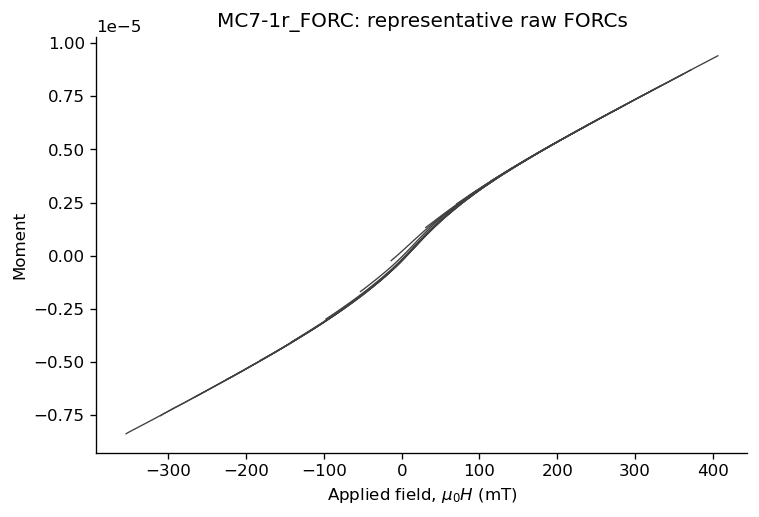

In [4]:
fig, ax = forc.plot_forc_curves(raw, fraction=0.12)
ax.set_title(f"{data_path.name}: representative raw FORCs")
plt.show()

## 5. Calibration drift

MicroMag FORC protocols interleave measurements at a calibration field. Long-term sensitivity drift changes the scale of an entire curve and should be corrected before taking derivatives.

The sources are not identical here. Active FORCinel 3.08 scales each moment by the first calibration divided by the interpolated calibration. The printed Egli (2013) equation 23 shows the inverse ratio, while FORCme subtracts the calibration change additively. PmagPy uses the active FORCinel behavior by default and exposes the literal alternatives as `egli_equation23` and `additive`, so a reported result is reproducible rather than silently conflating the three conventions.

The plot below shows raw calibration observations and the lightly smoothed series used for interpolation. Sharp calibration jumps deserve investigation; smoothing them away is not a substitute for rejecting unstable measurements.

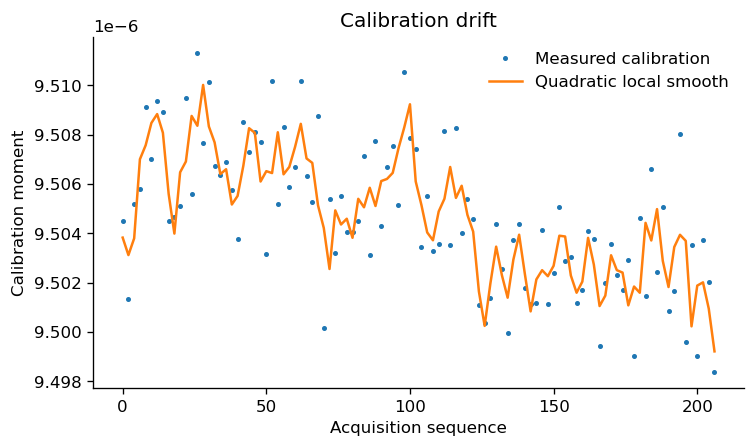

In [5]:
calibration_smooth = forc.smooth_calibrations(raw.calibration_moment, smoothing=2)
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(raw.calibration_sequence, raw.calibration_moment, ".", ms=4, label="Measured calibration")
ax.plot(raw.calibration_sequence, calibration_smooth, lw=1.5, label="Quadratic local smooth")
ax.set(xlabel="Acquisition sequence", ylabel="Calibration moment", title="Calibration drift")
ax.legend(frameon=False)
plt.show()

drift_corrected = forc.correct_drift(
    raw,
    method="multiplicative",
    interpolation="linear",
    smoothing=2,
)

## 6. Endpoint and lower-branch choices

The first and last points of a FORC are commonly affected by field sweep-rate changes. The active FORCinel 3.08 procedure excludes both points; FORCme replaces them by linear extrapolation from the interior. Here we use the conservative FORCinel choice and retain the coordinates as masked targets so the local fit can still reach the boundary.

Lower-branch subtraction is **off by default**. It is useful for centering the magnetization surface in some PCA or component-separation workflows, but finite local fits can be affected near data boundaries even though subtracting a function of $H$ alone does not change the ideal mixed derivative.

The implementation details matter because the packages accept somewhat different input layouts. FORCme's current segmentation expects calibration points to be attached to multi-point blocks, and its optional lower-branch reference is the first remaining FORC. Some MicroMag exports instead store calibrations as one-point blocks and begin with a very short high-reversal FORC. FORCinel pools low-reversal curves and permits its quadratic LOESS fit to extend beyond their measured fields. PmagPy retains the FORCme workflow while using a coverage-aware baseline: at every applied field it takes the median of the five lowest-reversal curves that **actually contain that field**, then smooths the resulting one-dimensional baseline. This avoids unsupported constant or long-polynomial extrapolation and the associated high-field tail.

Automatic outlier removal is also deliberately absent from this walkthrough. Diagnose suspect curves from raw data and residual structure, document any exclusions, and then recalculate.

In [6]:
conditioned = forc.adjust_endpoints(drift_corrected, method="drop", n=1)

conditioning = pd.Series({
    "raw finite moments": np.isfinite(raw.moment).sum(),
    "conditioned finite moments": np.isfinite(conditioned.moment).sum(),
    "masked endpoints": np.count_nonzero(~np.isfinite(conditioned.moment)),
})
display(conditioning.to_frame("count"))

,count
raw finite moments,8164
conditioned finite moments,7957
masked endpoints,207


## 7. Calculate both published estimates

Both calculations below use the same corrected measurements, output grid, normalized FORC definition, and HC3 heteroscedasticity-robust error estimator. Their difference therefore isolates the smoothing strategy.

`output_step=2` evaluates every second nominal field increment. This changes display density and run time, not the measured points included in each local fit. Use `output_step=1` when the densest output grid is important.

In [7]:
variforc_result = forc.calculate_forc(
    conditioned,
    method="variforc",
    sc0=3,
    sc1=7,
    sb0=3,
    sb1=7,
    lambda_c=0.07,
    lambda_b=0.07,
    output_step=2,
    error_method="hc3",
)

loess_result = forc.calculate_forc(
    conditioned,
    method="loess",
    smoothing_factor=3.0,
    output_step=2,
    error_method="hc3",
)

comparison = pd.DataFrame({
    "Harrison LOESS": {
        "finite output cells": np.isfinite(loess_result.rho).sum(),
        "median points per fit": np.nanmedian(loess_result.point_count[loess_result.point_count > 0]),
        "median |rho|/error": np.nanmedian(loess_result.signal_to_noise),
    },
    "VARIFORC": {
        "finite output cells": np.isfinite(variforc_result.rho).sum(),
        "median points per fit": np.nanmedian(variforc_result.point_count[variforc_result.point_count > 0]),
        "median |rho|/error": np.nanmedian(variforc_result.signal_to_noise),
    },
}).T
display(comparison)

,finite output cells,median points per fit,median |rho|/error
Harrison LOESS,1102.0,67.0,1.05628
VARIFORC,1102.0,414.0,1.66790


## 8. Compare the diagrams

The panels are independently normalized to their 99th percentile absolute amplitude. This is appropriate for comparing shape and resolution, but **not** for comparing absolute FORC amplitude. For quantitative amplitude, set `normalize=False` and use common color limits.

Ask three questions while comparing the panels:

1. Does the central ridge at $H_u\approx0$ broaden vertically under isotropic LOESS?
2. Does increased VARIFORC smoothing away from the ridge suppress background noise without erasing coherent structure?
3. Are edge features supported by enough measurements and adequate signal-to-noise?

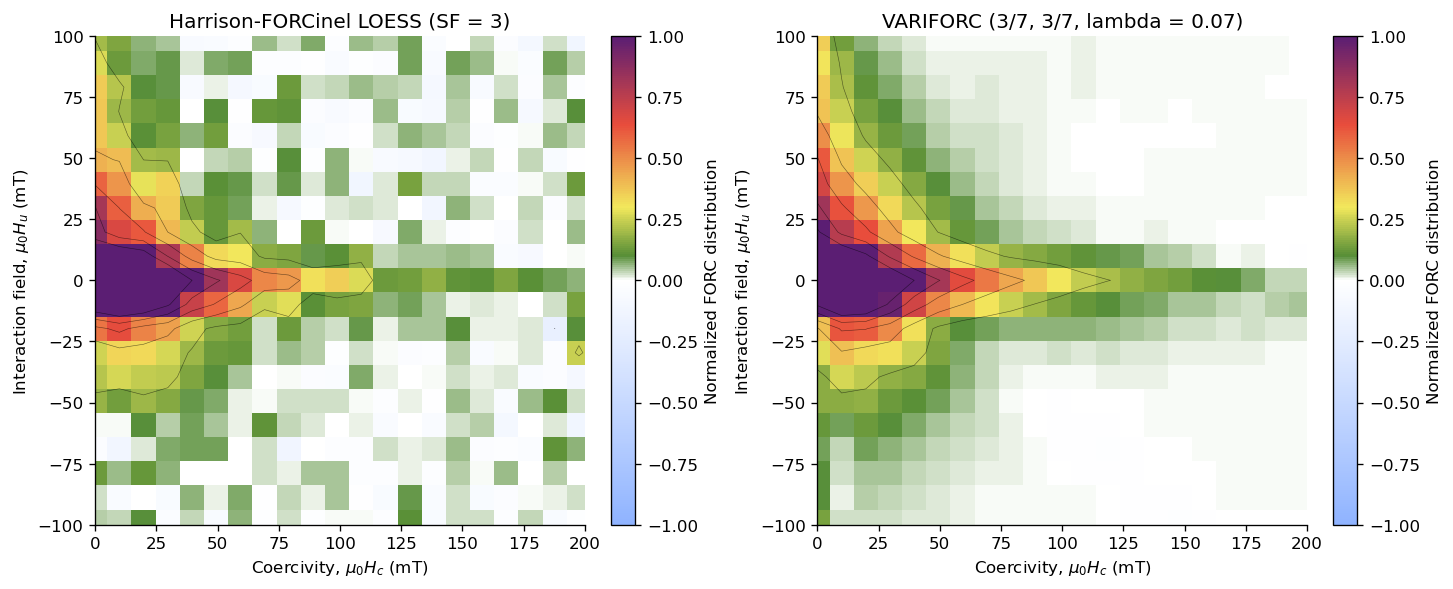

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
forc.plot_forc(
    loess_result, ax=axes[0], normalize=True, percentile=99,
    hc_limits=(0, 200), hu_limits=(-100, 100)
)
axes[0].set_title("Harrison-FORCinel LOESS (SF = 3)")
forc.plot_forc(
    variforc_result, ax=axes[1], normalize=True, percentile=99,
    hc_limits=(0, 200), hu_limits=(-100, 100)
)
axes[1].set_title("VARIFORC (3/7, 3/7, lambda = 0.07)")
plt.show()

## 9. Inspect the actual VARIFORC smoothing

A parameter label such as “3/7” is incomplete because the local factors change with position. These maps show the regression half-widths actually used, in nominal field-step units. Near the central ridge, $s_b$ remains small to protect vertical resolution. Away from it, $s_b$ increases. The same transition around $H_c=0$ controls $s_c$ when a vertical ridge may be present.

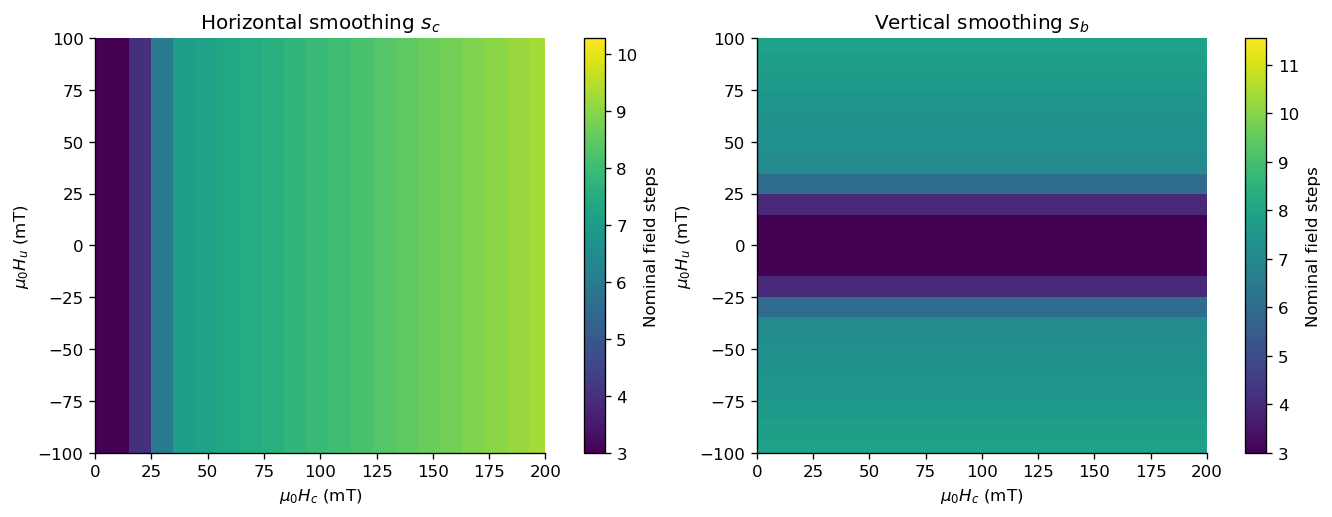

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
for axis, values, title in zip(
    axes,
    [variforc_result.sc, variforc_result.sb],
    ["Horizontal smoothing $s_c$", "Vertical smoothing $s_b$"],
):
    image = axis.pcolormesh(
        variforc_result.hc * 1e3,
        variforc_result.hu * 1e3,
        values,
        shading="auto",
        cmap="viridis",
    )
    fig.colorbar(image, ax=axis, label="Nominal field steps")
    axis.set(xlabel="$\\mu_0H_c$ (mT)", ylabel="$\\mu_0H_u$ (mT)", title=title)
    axis.set_xlim(0, 200)
    axis.set_ylim(-100, 100)
plt.show()

## 10. Use uncertainty, not color alone

The default HC3 covariance estimate allows non-constant residual variance within a local fit. The diagnostic below plots $|\rho|/\delta\rho$. Egli (2013) recommends highlighting a signal-to-noise ratio near 3 as a rapid significance guide; exact thresholds also depend on effective degrees of freedom and the chosen confidence level.

Isolated cells above 3 are not automatically meaningful. Prefer spatially coherent regions, check whether they repeat under nearby smoothing parameters, and relate them back to the raw curves.

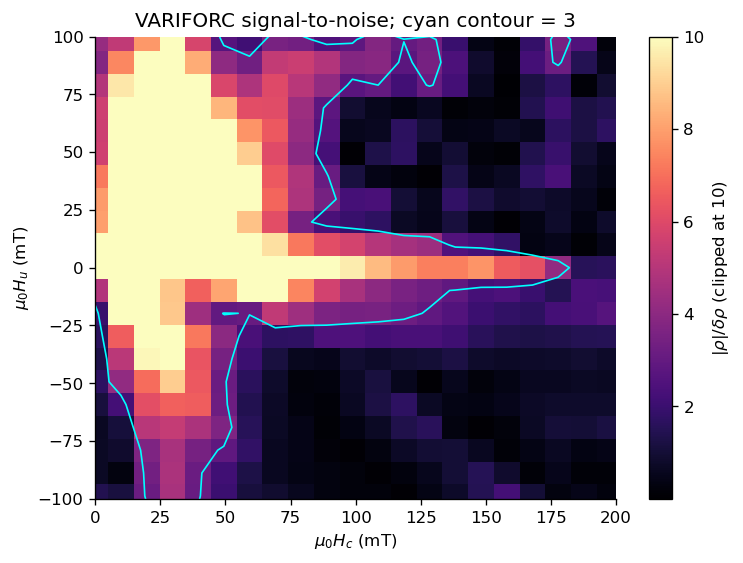

Cells with |rho|/error >= 3: 29.4%


In [10]:
snr = variforc_result.signal_to_noise
fig, ax = plt.subplots(figsize=(7, 5))
image = ax.pcolormesh(
    variforc_result.hc * 1e3,
    variforc_result.hu * 1e3,
    np.clip(snr, 0, 10),
    shading="auto",
    cmap="magma",
)
ax.contour(
    variforc_result.hc * 1e3,
    variforc_result.hu * 1e3,
    snr,
    levels=[3],
    colors="cyan",
    linewidths=1.0,
)
fig.colorbar(image, ax=ax, label="$|\\rho|/\\delta\\rho$ (clipped at 10)")
ax.set(
    xlabel="$\\mu_0H_c$ (mT)", ylabel="$\\mu_0H_u$ (mT)",
    title="VARIFORC signal-to-noise; cyan contour = 3",
    xlim=(0, 200), ylim=(-100, 100),
)
plt.show()

finite_snr = np.isfinite(snr)
print(f"Cells with |rho|/error >= 3: {100*np.mean(snr[finite_snr] >= 3):.1f}%")

## 11. Extract a reproducible profile

A horizontal profile at $H_u=0$ summarizes coercivity structure along the central ridge. `forc_profile` selects the nearest calculated grid row and returns unnormalized $\rho$. Report the requested cut, the actual grid spacing, the smoothing parameters, and whether the displayed profile was additionally smoothed. No extra profile smoothing is applied here.

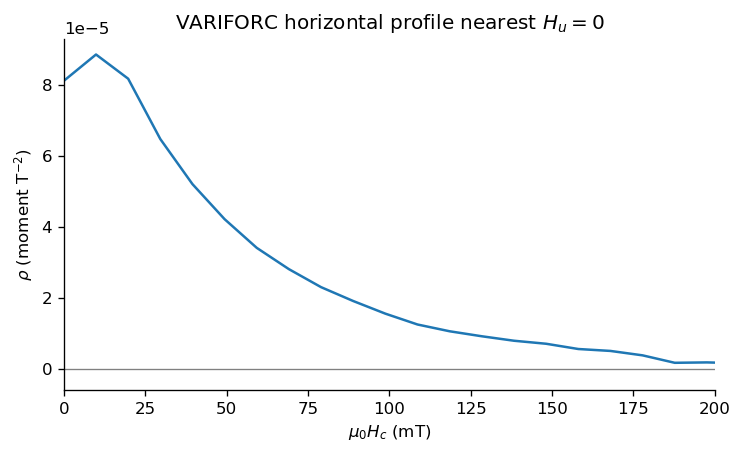

In [11]:
hc_profile, rho_profile = forc.forc_profile(variforc_result, axis="hc", value=0.0)
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(hc_profile * 1e3, rho_profile, lw=1.5)
ax.axhline(0, color="0.5", lw=0.8)
ax.set(
    xlabel="$\\mu_0H_c$ (mT)",
    ylabel="$\\rho$ (moment T$^{-2}$)",
    title="VARIFORC horizontal profile nearest $H_u=0$",
    xlim=(0, 200),
)
plt.show()

## 12. Reproducible one-call processing

After the individual decisions have been inspected, the same workflow can be reproduced with one call. Keep the arguments in an analysis script or notebook rather than relying on defaults alone.

In [12]:
one_call_output = forc.run_forc_pipeline(
    data_path,
    method="variforc",
    drift=True,
    drift_method="multiplicative",
    drift_fit="linear",
    drift_smoothing=2,
    endpoint_method="drop",
    endpoint_replace_n=1,
    do_lower_branch_subtract=False,
    sc0=3,
    sc1=7,
    sb0=3,
    sb1=7,
    lambda_c=0.07,
    lambda_b=0.07,
    output_step=2,
    error_method="hc3",
)
one_call = one_call_output["result"]

assert np.allclose(one_call.rho, variforc_result.rho, equal_nan=True)
print("The one-call result reproduces the staged calculation.")

The one-call result reproduces the staged calculation.


## 13. Process every supplied example

The same audited settings are now applied to **every file currently present** in `example_data/FORC` using FORCme's familiar batch-pipeline organization. Each file is read and conditioned independently; measurements are not stacked or averaged across specimens.

For each dataset, the notebook retains three explicit stages:

1. **Original FORCs** - measured moment-field curves exactly as parsed.
2. **Conditioned FORCs** - multiplicative calibration-drift correction, removal of the first and last point, and subtraction of a smooth coverage-aware baseline. At each field, the baseline uses the five lowest-reversal curves that contain a measurement there.
3. **Final FORC distribution** - variable, anisotropic local quadratic smoothing followed by the mixed second derivative.

The final calculation uses `output_step=1`, so every nominal output-grid position supported by the measurements is evaluated. This is the highest calculation-grid density available from the measured field increment. No display upsampling is used, because interpolation could make a plot look denser without adding scientific resolution. Final diagrams use FORCme's green-red version-2 colormap exactly: light blue for negative values, white at zero, and green-yellow-red-purple for positive values.

Lower-branch subtraction is not universally appropriate. It is applied here because this walkthrough explicitly demonstrates baseline removal; analyses intended to retain the uncentered magnetization surface should repeat the calculation with baseline subtraction disabled. The coverage-aware estimator is used instead of FORCme's first-FORC constant extension or FORCinel's potentially long quadratic extrapolation.

In [13]:
data_dir = data_path.parent
batch_outputs = forc.run_forc_pipeline(
    data_dir,
    mode="b",
    file_type="*",
    method="variforc",
    drift=True,
    drift_method="multiplicative",
    drift_fit="linear",
    drift_smoothing=2,
    endpoint_method="drop",
    endpoint_replace_n=1,
    do_lower_branch_subtract=True,
    lower_branch_curves=5,
    lower_branch_smoothing=2,
    sc0=3,
    sc1=7,
    sb0=3,
    sb1=7,
    lambda_c=0.07,
    lambda_b=0.07,
    output_step=1,
    error_method="hc3",
)

all_processing = {}
batch_rows = []
for output in batch_outputs:
    path = Path(output["input_path"])
    original = output["raw"]
    processed = output["processed"]
    result = output["result"]
    all_processing[path.name] = {
        "original": original,
        "processed": processed,
        "baseline_field": output["baseline_field"],
        "baseline_moment": output["baseline_moment"],
        "result": result,
    }
    finite_rho = np.isfinite(result.rho)
    finite_snr = np.isfinite(result.signal_to_noise)
    batch_rows.append({
        "sample": path.name,
        "FORCs": original.n_curves,
        "measurements": original.moment.size,
        "field step (mT)": 1e3 * result.parameters["field_step_T"],
        "rho grid": f"{result.rho.shape[0]} x {result.rho.shape[1]}",
        "finite rho cells": int(finite_rho.sum()),
        "median points/fit": float(np.nanmedian(result.point_count[result.point_count > 0])),
        "99th percentile |rho|": float(np.nanpercentile(np.abs(result.rho[finite_rho]), 99)),
        "cells with S/N >= 3 (%)": float(100 * np.mean(result.signal_to_noise[finite_snr] >= 3)),
    })

batch_summary = pd.DataFrame(batch_rows).set_index("sample")
display(batch_summary)

assert len(all_processing) == len(batch_outputs)
assert all(np.isfinite(item["result"].rho).any() for item in all_processing.values())

,FORCs,measurements,field step (mT),rho grid,finite rho cells,median points/fit,99th percentile |rho|,cells with S/N >= 3 (%)
sample,,,,,,,,
AX21-7-sc_FORC,124,9214,2.963490,125 x 47,4746,448.0,0.000020,34.555415
AX21-7-sub2_FORC,104,8164,4.938620,105 x 54,4235,434.0,0.000076,40.000000
BD2-2r_FORC,104,8164,4.938985,105 x 54,4235,434.0,0.000835,49.988194
MA1-5-r_FORC.txt,160,24898,3.000000,161 x 134,12661,660.0,0.000065,55.027249
MA1-OX-r FORC.txt,333,105919,2.001136,334 x 263,53387,1187.0,0.000671,57.180587
MC7-1r_FORC,104,8164,4.938720,105 x 54,4235,434.0,0.000050,33.341204
SJ1-4_forc.txt,140,17960,2.001271,141 x 100,9148,571.0,0.000073,26.759948
TH1-2-r.forc,76,5504,5.000000,76 x 60,2790,390.0,0.000150,57.096774
WS3-5-r.forc,76,5504,5.000000,76 x 60,2790,390.0,0.000163,48.530466


### Per-dataset processing panels

Each figure below uses the same ordering. The middle panel is shown immediately before local regression, so its changes relative to the raw curves come only from the documented calibration, endpoint, and coverage-aware baseline operations. It should remain centered across the full measured field range; a systematic high-field rise would indicate unsupported baseline extrapolation. Smoothing enters in the final panel through the VARIFORC local quadratic fit. Final panels are independently normalized to their 99th-percentile absolute amplitude; consult the table above for quantitative amplitude comparisons.

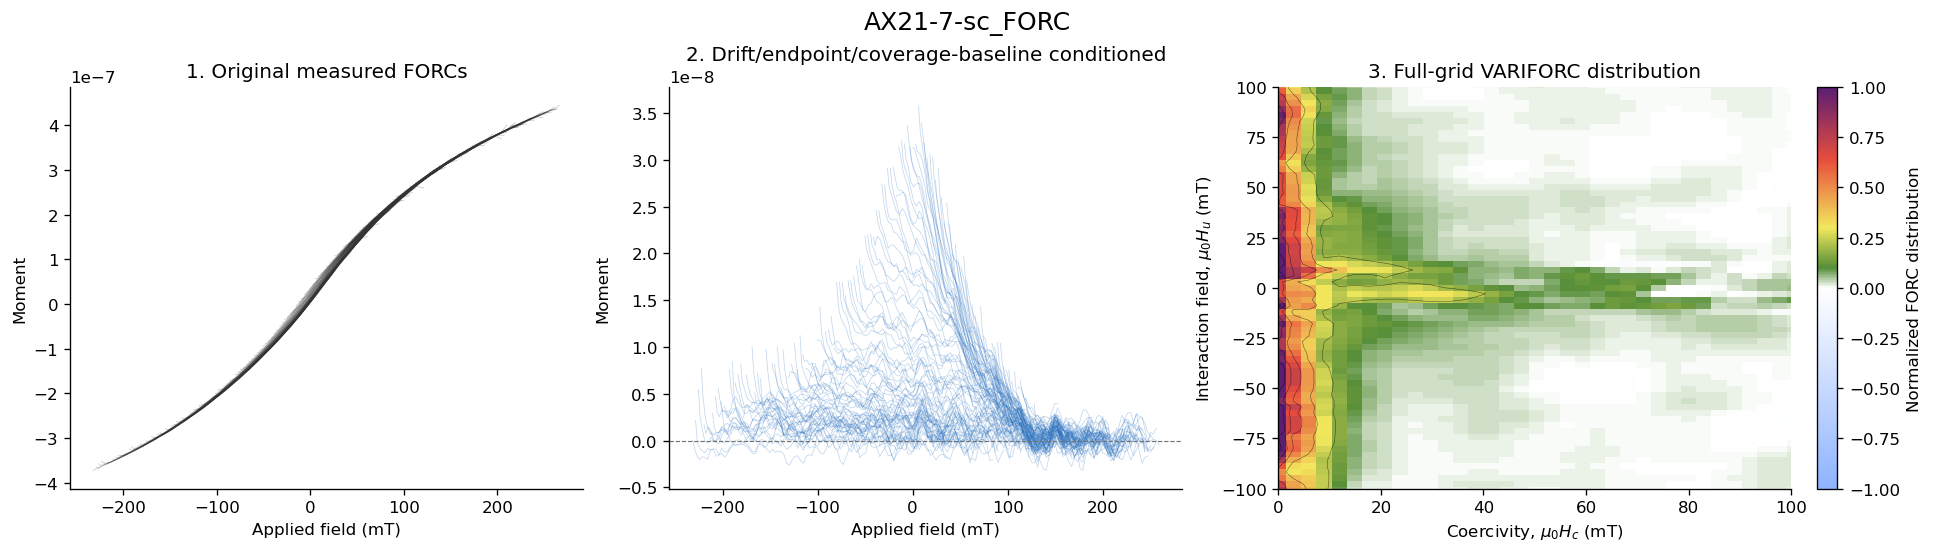

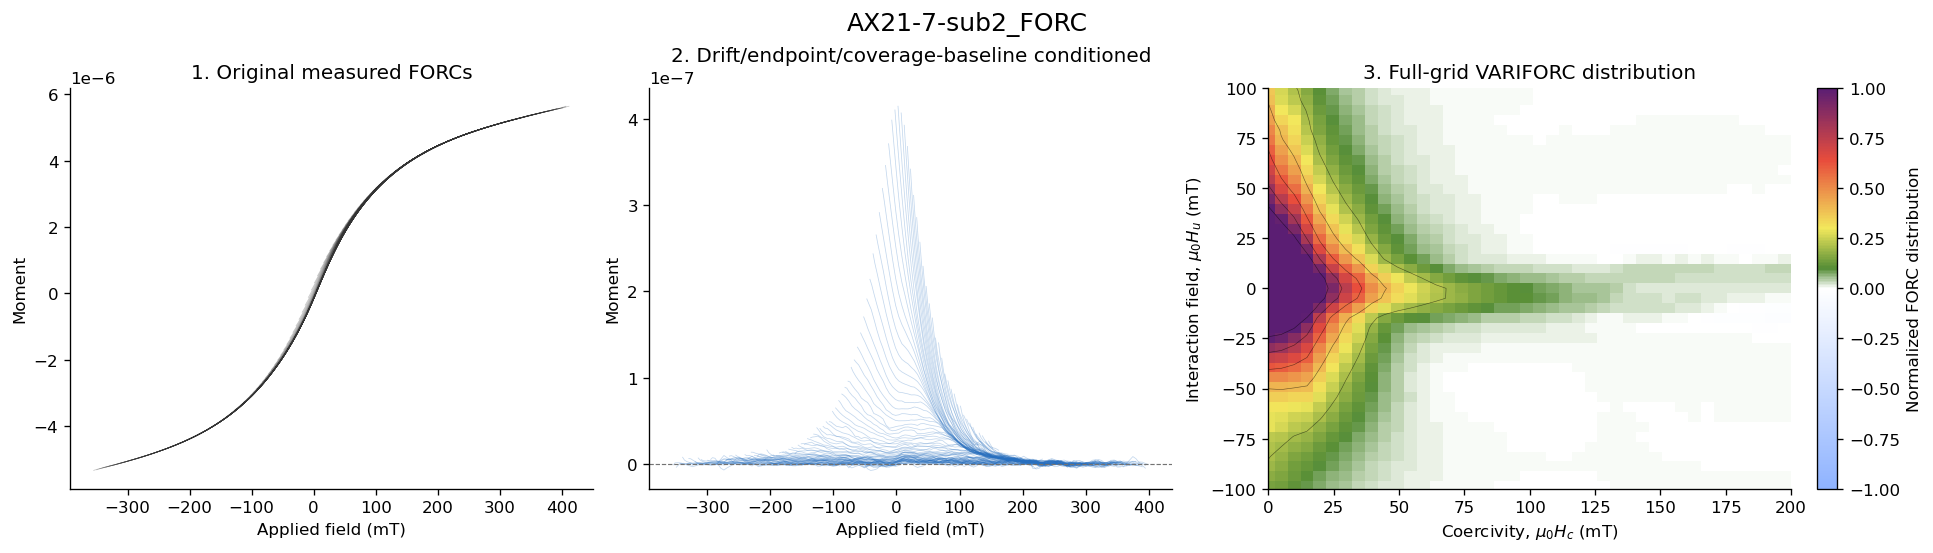

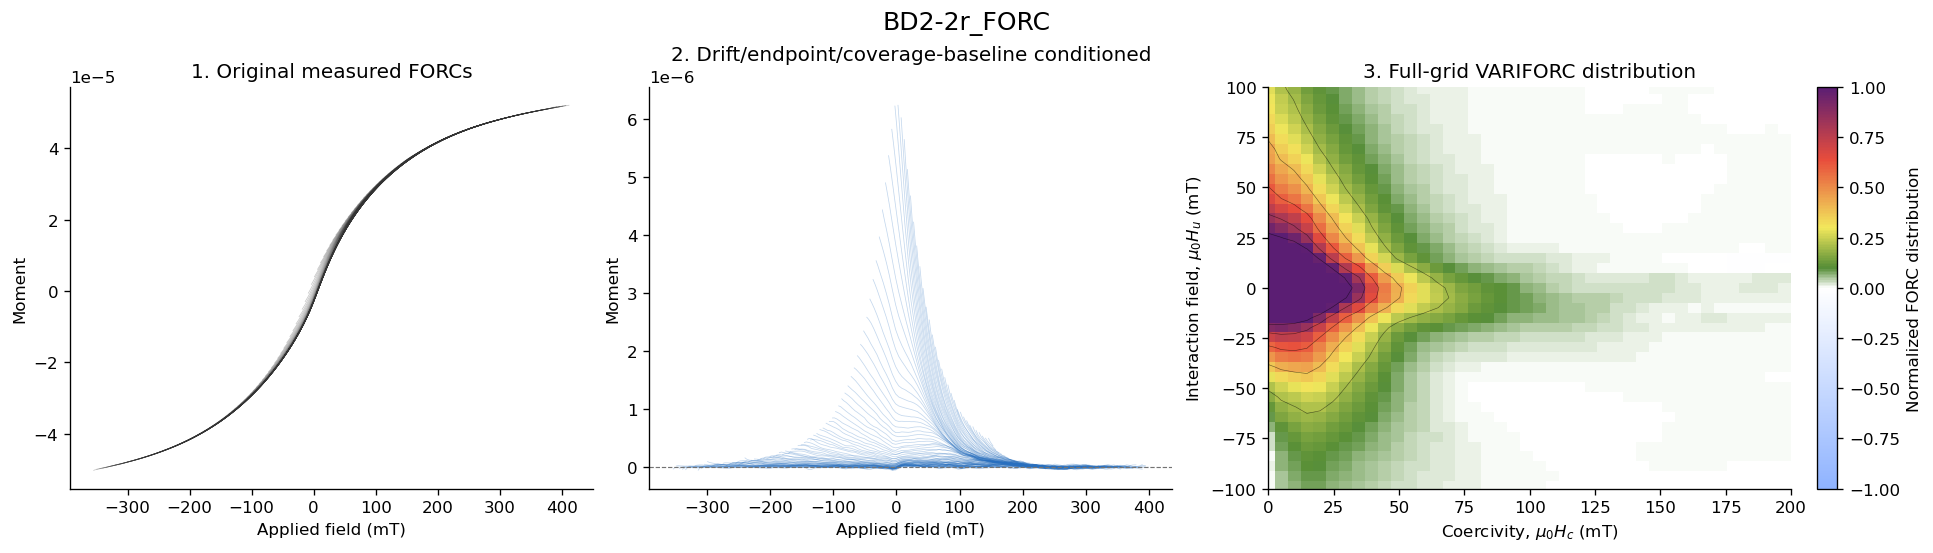

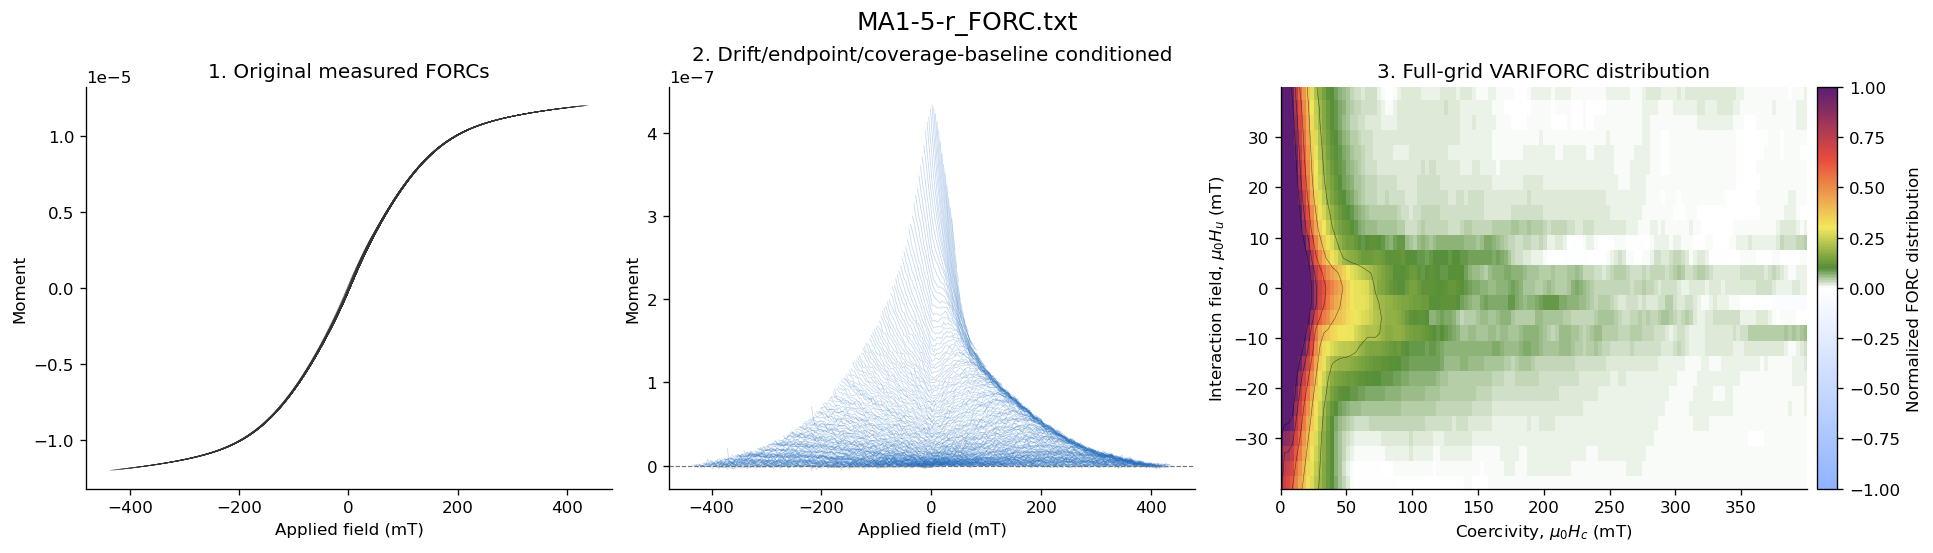

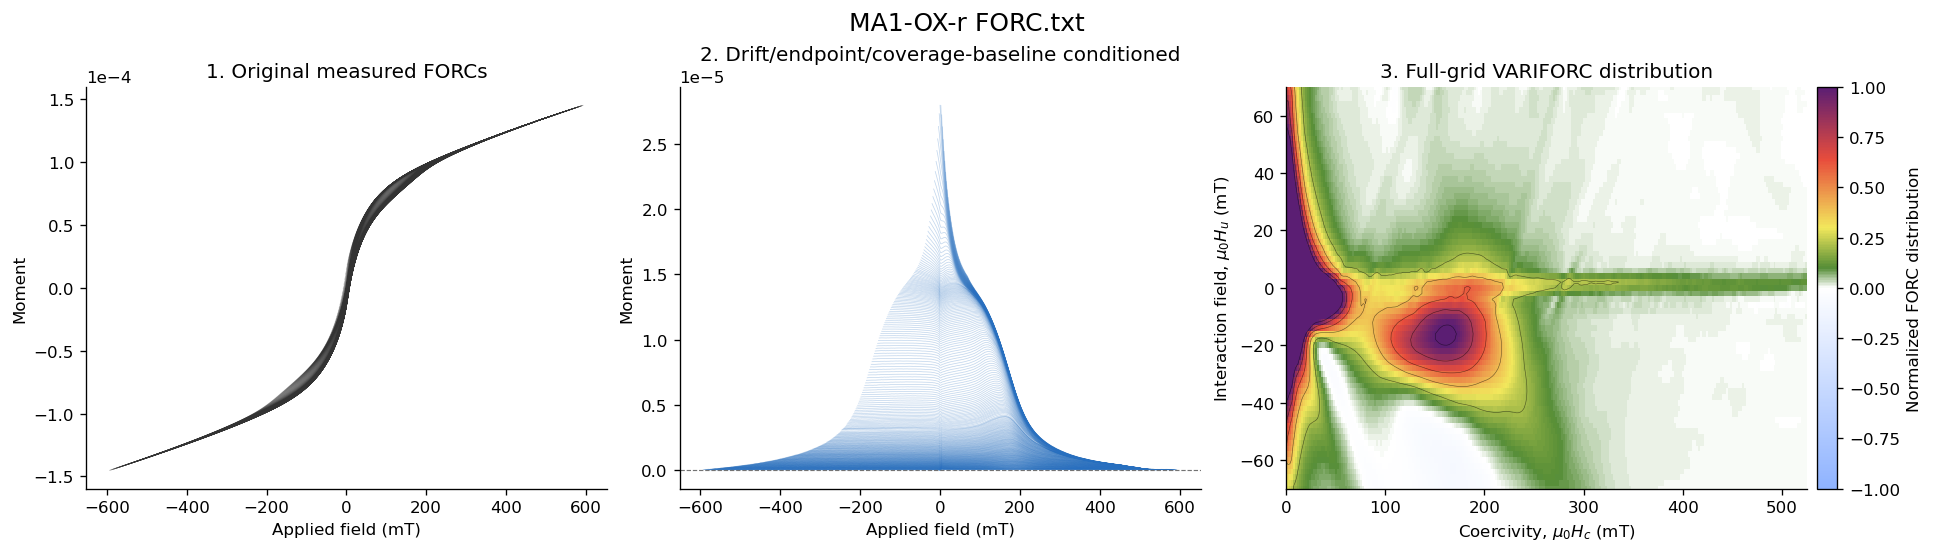

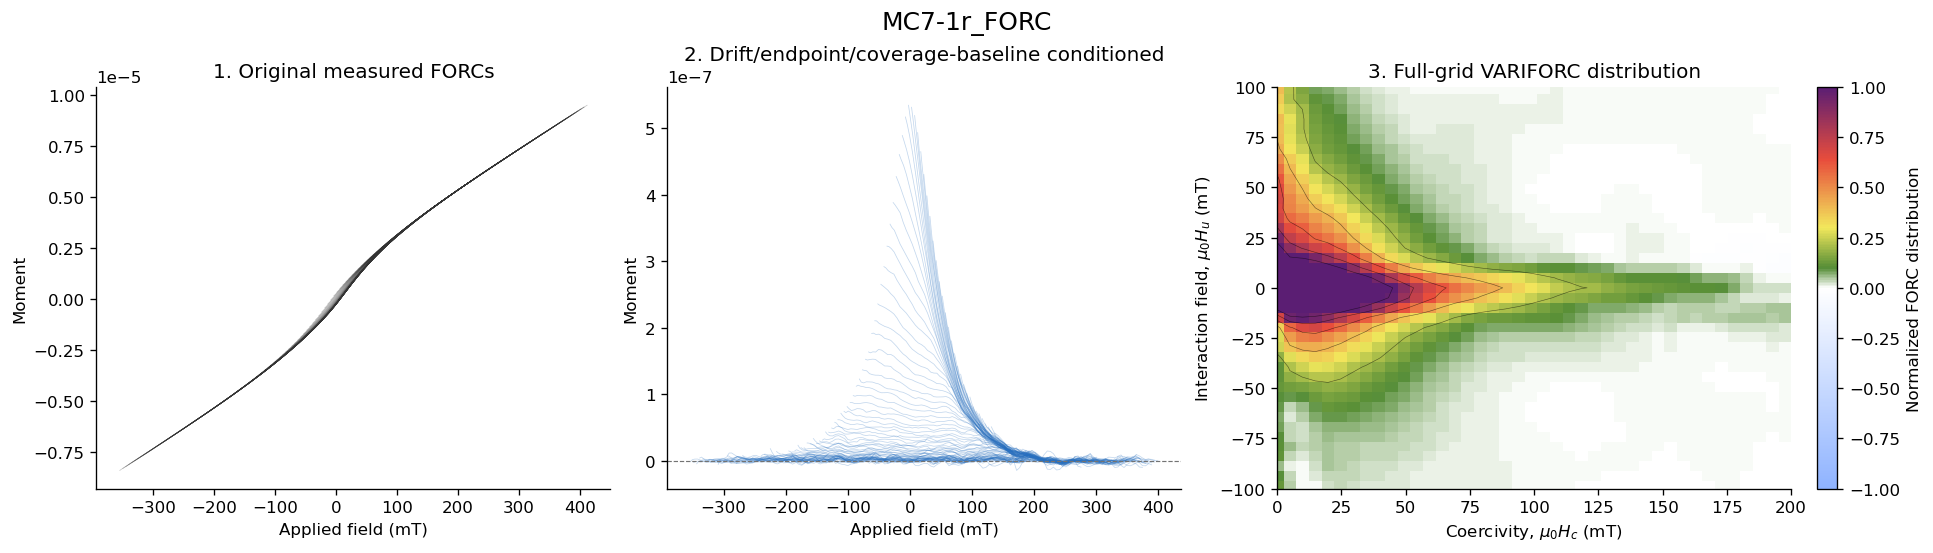

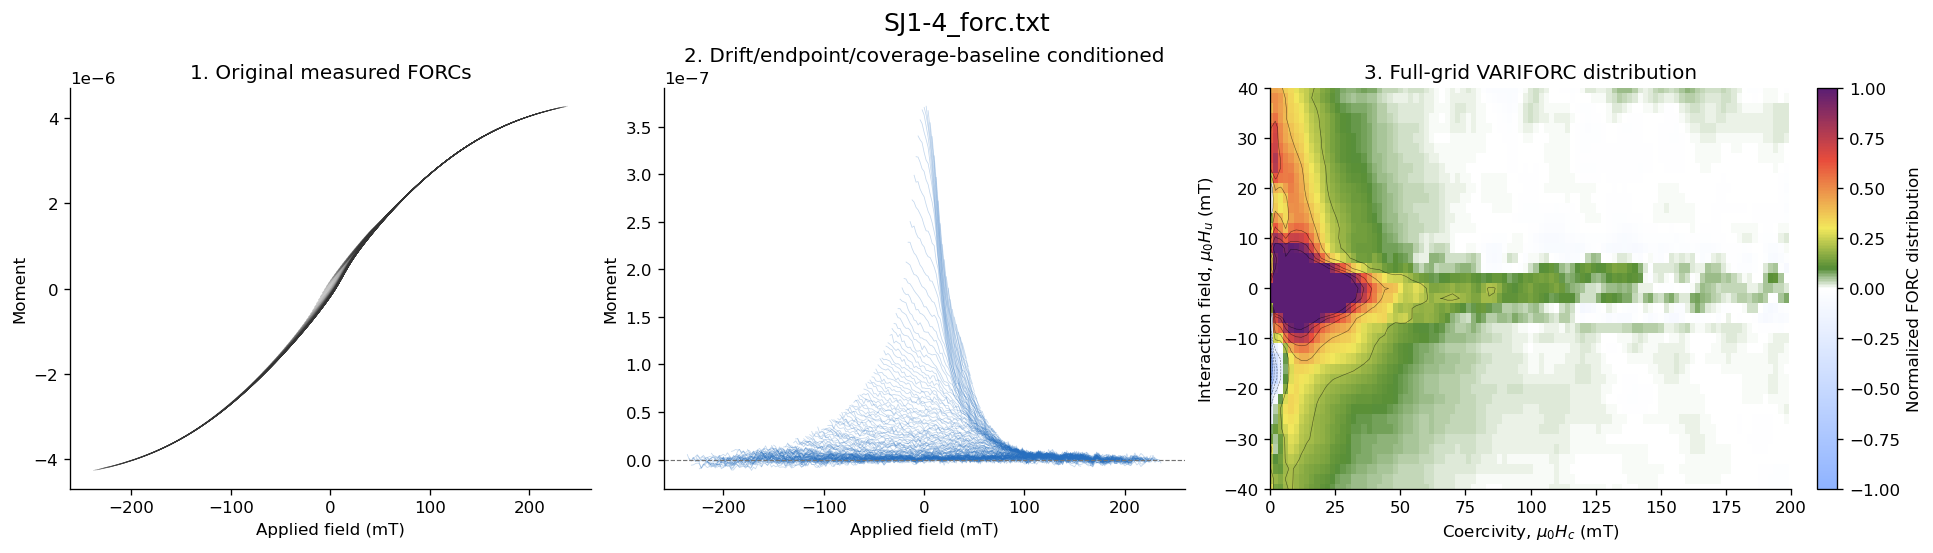

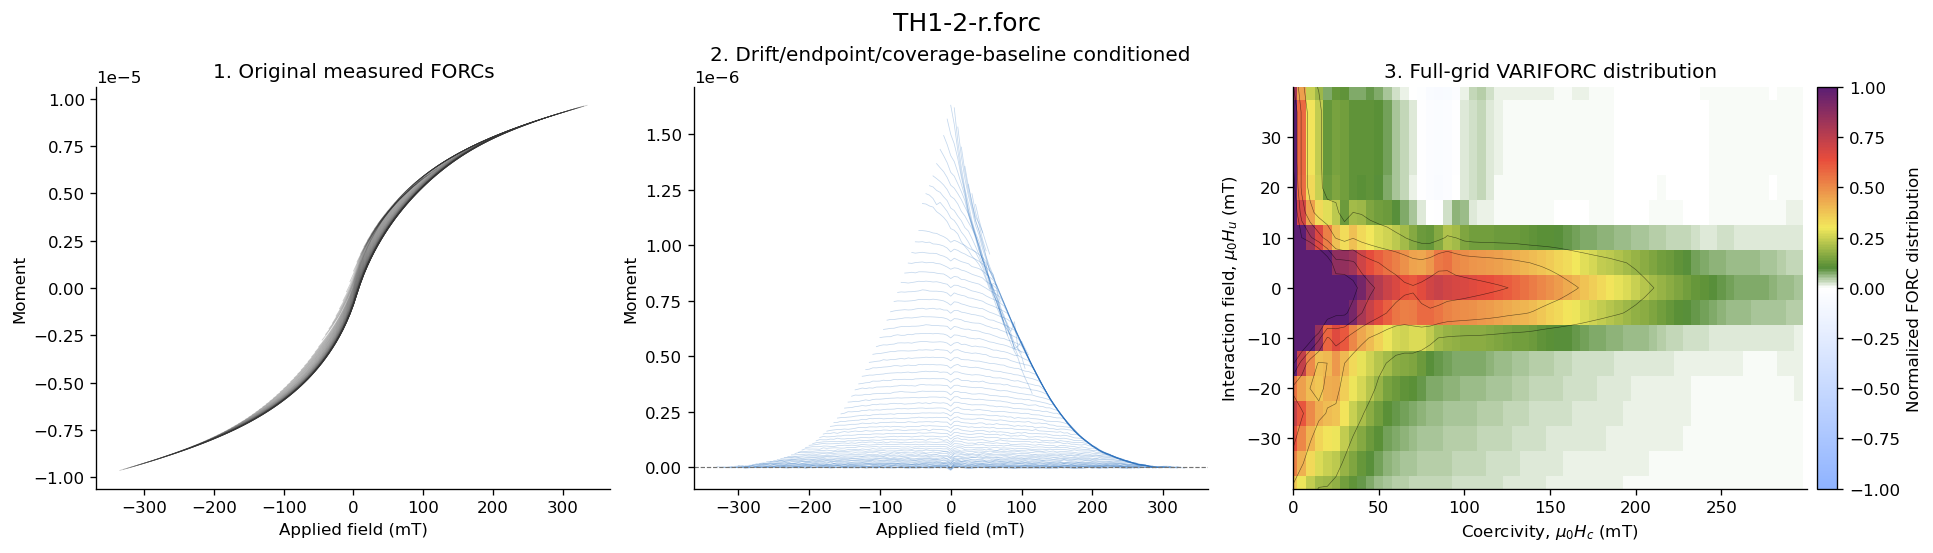

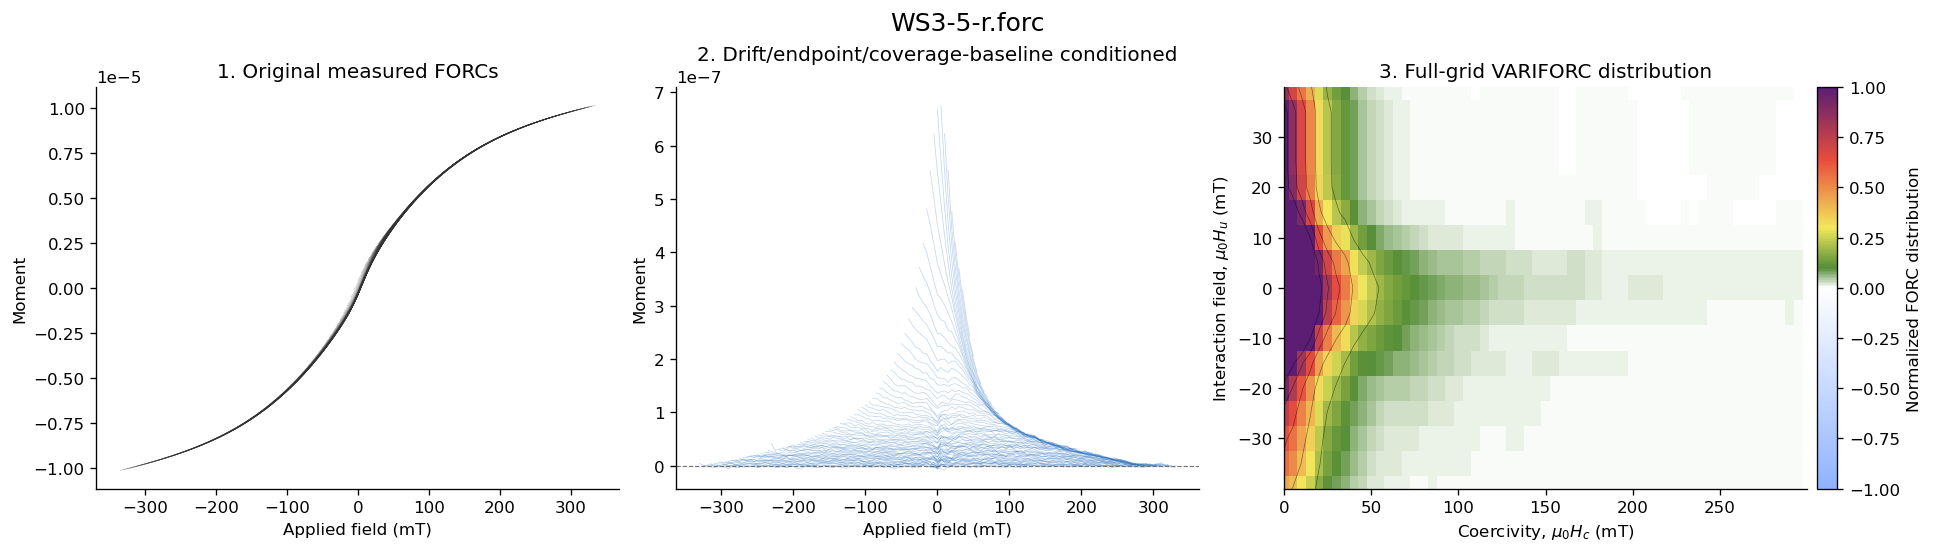

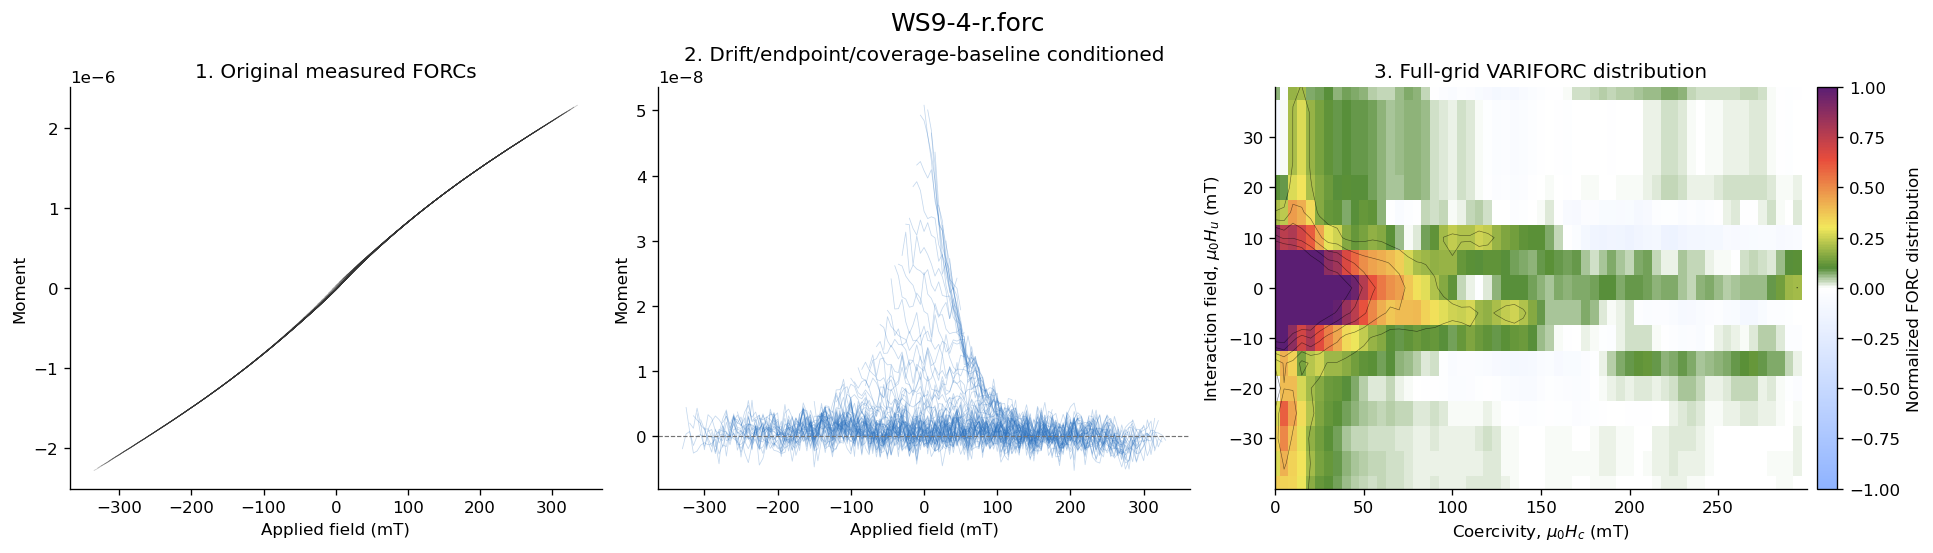

In [14]:
def plot_curve_family(axis, data, color, alpha=0.28):
    '''Plot every measured curve with a light line so dense runs remain legible.'''
    for curve_number in range(data.n_curves):
        select = data.curve == curve_number
        axis.plot(
            data.field[select] * 1e3,
            data.moment[select],
            color=color,
            linewidth=0.45,
            alpha=alpha,
        )
    axis.set_xlabel("Applied field (mT)")
    axis.set_ylabel("Moment")
    axis.ticklabel_format(axis="y", style="sci", scilimits=(-3, 3))


for sample_name, item in all_processing.items():
    original = item["original"]
    processed = item["processed"]
    result = item["result"]

    figure, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
    plot_curve_family(axes[0], original, color="0.20")
    axes[0].set_title("1. Original measured FORCs")

    plot_curve_family(axes[1], processed, color="#276FBF")
    axes[1].axhline(0, color="0.45", linewidth=0.7, linestyle="--")
    axes[1].set_title("2. Drift/endpoint/coverage-baseline conditioned")

    hc_header = forc.metadata_value(result.data.metadata, "Hc2")
    hu_header = forc.metadata_value(result.data.metadata, "Hb2")
    hc_max = 1e3 * hc_header if hc_header is not None else float(np.nanmax(result.hc) * 1e3)
    hu_max = abs(1e3 * hu_header) if hu_header is not None else float(np.nanmax(np.abs(result.hu)) * 1e3)
    forc.plot_forc(
        result,
        ax=axes[2],
        normalize=True,
        percentile=99,
        hc_limits=(0, hc_max),
        hu_limits=(-hu_max, hu_max),
    )
    axes[2].set_title("3. Full-grid VARIFORC distribution")

    figure.suptitle(sample_name, fontsize=15)
    plt.show()

## 14. Interpretation and reporting checklist

Before interpreting domains, interactions, or mineral components:

- Confirm the measurement and moment units from the source header.
- Show representative raw curves and the calibration series.
- State the drift model, endpoint treatment, and any rejected measurements.
- Report the algorithm and all smoothing parameters. For VARIFORC this includes $s_{c,0}$, $s_{c,1}$, $s_{b,0}$, $s_{b,1}$, $\lambda_c$, $\lambda_b$, and any ridge offset.
- Distinguish display normalization and interpolation from the scientific regression.
- Inspect point-count and signal-to-noise support, especially at boundaries.
- Repeat the calculation over a reasonable neighborhood of smoothing settings. A feature that exists only for one setting is not robust.
- Do not compare absolute $\rho$ values between software packages until their factor-of-two convention and normalization are confirmed.

### References

- Harrison, R. J., and J. M. Feinberg (2008), *FORCinel: An improved algorithm for calculating first-order reversal curve distributions using locally weighted regression smoothing*, **G3**, 9, Q05016. https://doi.org/10.1029/2008GC001987
- Egli, R. (2013), *VARIFORC: An optimized protocol for calculating non-regular first-order reversal curve (FORC) diagrams*, **Global and Planetary Change**, 110, 302-320. https://doi.org/10.1016/j.gloplacha.2013.08.003
- Heslop, D., and A. P. Roberts (2012), Estimation and propagation of uncertainties associated with first-order reversal curve distributions, *Journal of Geophysical Research*, 117, B11101.
- Brown, M. (2026), *FORCme: Application of machine code and adaptive smoothing within Python for the rapid processing of First Order Reversal Curves*, version 1.0.0. Workflow naming and colormaps used under the MIT License.